# AISR LAB EXPERIMENT 6

---


## SIMPLE NEURAL NETWORK USING PYTHON

---



**NAME:** SAKSHI BHATT <br>
**SAP ID:** 500121811 <br>
**BATCH:** B8<br>
**COURSE:** ALGORITHMS FOR INTELLIGENT SYSTEMS AND ROBOTICS LAB

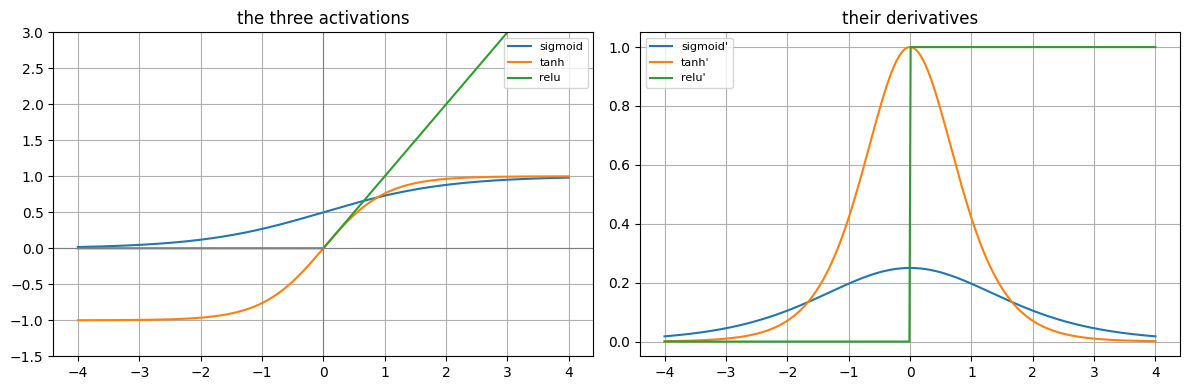

derivative of relu for z > 0 : 1.0
derivative of relu for z < 0 : 0.0  <- this is the cause of the dying relu problem
largest derivative of sigmoid: 0.25


In [1]:
import numpy as np
import matplotlib.pyplot as plt
def sigmoid(z):
    return 1 / (1 + np.exp(-z))
def sigmoid_derivative(a):
    return a * (1 - a)
def relu(z):
    return np.maximum(0, z)
def relu_derivative(a):
    # a is the output of relu, it is positive exactly where z was positive
    return (a > 0).astype(float)
z = np.linspace(-4, 4, 400)
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(z, sigmoid(z), label="sigmoid")
plt.plot(z, np.tanh(z), label="tanh")
plt.plot(z, relu(z), label="relu")
plt.axhline(0, color='gray', linewidth=0.8); plt.axvline(0, color='gray', linewidth=0.8)
plt.ylim(-1.5, 3)
plt.title("the three activations"); plt.legend(fontsize=8); plt.grid(True)
plt.subplot(1,2,2)
plt.plot(z, sigmoid_derivative(sigmoid(z)), label="sigmoid'")
plt.plot(z, 1-np.tanh(z)**2, label="tanh'")
plt.plot(z, relu_derivative(relu(z)), label="relu'")
plt.title("their derivatives"); plt.legend(fontsize=8); plt.grid(True)
plt.tight_layout()
plt.show()
print("derivative of relu for z > 0 :", relu_derivative(relu(2.0)))
print("derivative of relu for z < 0 :", relu_derivative(relu(-2.0)), " <- this is the cause of the dying relu problem")
print("largest derivative of sigmoid:", round(sigmoid_derivative(sigmoid(0)), 3))

In [2]:
X = np.array([[0,0], [0,1], [1,0], [1,1]], dtype=float)
y_and = np.array([0, 0, 0, 1], dtype=float)
y_or  = np.array([0, 1, 1, 1], dtype=float)
y_xor = np.array([0, 1, 1, 0], dtype=float)
def train_single_neuron(X, y, lr=0.5, epochs=5000, seed=3):
    rng = np.random.default_rng(seed)
    w = rng.normal(0, 0.5, X.shape[1]); b = 0.0
    history = []
    for e in range(epochs):
        a = sigmoid(X @ w + b)
        history.append(np.mean((a - y)**2))
        delta = (a - y) * sigmoid_derivative(a) * 2 / len(y)
        w = w - lr * (X.T @ delta); b = b - lr * delta.sum()
    return w, b, history
for name, target in [("AND", y_and), ("OR", y_or), ("XOR", y_xor)]:
    w, b, hist = train_single_neuron(X, target)
    pred = (sigmoid(X @ w + b) > 0.5).astype(int)
    print(name.ljust(4), ": predicted", pred, " expected", target.astype(int),
          " accuracy", (pred == target).mean(), " loss", round(hist[-1], 4))

AND  : predicted [0 0 0 1]  expected [0 0 0 1]  accuracy 1.0  loss 0.0021
OR   : predicted [0 1 1 1]  expected [0 1 1 1]  accuracy 1.0  loss 0.0011
XOR  : predicted [0 0 0 0]  expected [0 1 1 0]  accuracy 0.5  loss 0.25


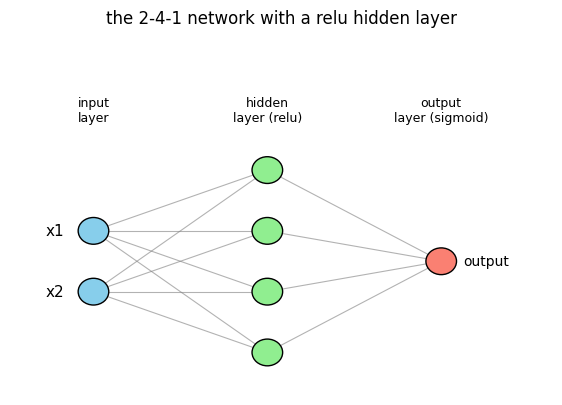

parameters : 17


In [3]:
def draw_network(layer_sizes, title="network structure"):
    fig, ax = plt.subplots(figsize=(7,4.5))
    v_gap, h_gap = 1.0, 2.5
    positions = []
    for l, n in enumerate(layer_sizes):
        ys = np.linspace((n-1)*v_gap/2, -(n-1)*v_gap/2, n)
        positions.append([(l*h_gap, y) for y in ys])
    for l in range(len(layer_sizes)-1):
        for (x1,y1) in positions[l]:
            for (x2,y2) in positions[l+1]:
                ax.plot([x1,x2],[y1,y2], color='gray', linewidth=0.8, alpha=0.6, zorder=1)
    colours = ['skyblue','lightgreen','salmon']
    for l, layer in enumerate(positions):
        for i,(x,y) in enumerate(layer):
            ax.add_patch(plt.Circle((x,y),0.22, color=colours[l%3], ec='black', zorder=2))
            if l==0: ax.text(x-0.55,y,"x"+str(i+1),ha='center',va='center',fontsize=11)
            if l==len(positions)-1: ax.text(x+0.65,y,"output",ha='center',va='center',fontsize=10)
    top=max(y for layer in positions for (x,y) in layer)
    for l,nm in enumerate(["input\nlayer","hidden\nlayer (relu)","output\nlayer (sigmoid)"]):
        ax.text(l*h_gap, top+0.75, nm, ha='center', va='bottom', fontsize=9)
    ax.set_xlim(-1.2,(len(layer_sizes)-1)*h_gap+1.6); ax.set_ylim(-2.2, top+2.0)
    ax.axis('off'); ax.set_title(title, pad=18); plt.show()
draw_network([2,4,1], "the 2-4-1 network with a relu hidden layer")
print("parameters :", 2*4 + 4 + 4*1 + 1)

In [4]:
def init_network(n_input, n_hidden, seed=6):
    rng = np.random.default_rng(seed)
    return {"W1": rng.normal(0, 0.8, (n_input, n_hidden)),
            "b1": np.zeros(n_hidden) + 0.01,     # a small positive bias so that relu starts alive
            "W2": rng.normal(0, 0.8, (n_hidden, 1)),
            "b2": np.zeros(1)}
def forward(net, X):
    A1 = relu(X @ net["W1"] + net["b1"])
    A2 = sigmoid(A1 @ net["W2"] + net["b2"])
    return A1, A2
def backward(net, X, y, A1, A2, lr):
    m = len(y); Y = y.reshape(-1,1)
    d2 = (A2 - Y) * sigmoid_derivative(A2) * 2 / m
    d1 = (d2 @ net["W2"].T) * relu_derivative(A1)      # zero wherever the neuron is off
    net["W2"] = net["W2"] - lr * (A1.T @ d2)
    net["b2"] = net["b2"] - lr * d2.sum(axis=0)
    net["W1"] = net["W1"] - lr * (X.T @ d1)
    net["b1"] = net["b1"] - lr * d1.sum(axis=0)
    return net
def train_network(X, y, n_hidden=4, lr=0.1, epochs=6000, seed=6):
    net = init_network(X.shape[1], n_hidden, seed=seed)
    history = []
    for e in range(epochs):
        A1, A2 = forward(net, X)
        history.append(np.mean((A2 - y.reshape(-1,1))**2))
        net = backward(net, X, y, A1, A2, lr)
    return net, history

In [5]:
net, history = train_network(X, y_xor, n_hidden=4, seed=6)
A1, A2 = forward(net, X)
pred = (A2.ravel() > 0.5).astype(int)
print("input      output    predicted   expected")
for i in range(4):
    print(X[i], "   ", round(A2.ravel()[i], 4), "     ", pred[i], "         ", int(y_xor[i]))
print()
print("accuracy   :", (pred == y_xor).mean())
print("final loss :", round(history[-1], 6))
print()
print("hidden layer output for the four inputs :")
print(np.round(A1, 3))

input      output    predicted   expected
[0. 0.]     0.0284       0           0
[0. 1.]     0.9781       1           1
[1. 0.]     0.9672       1           1
[1. 1.]     0.0269       0           0

accuracy   : 1.0
final loss : 0.000773

hidden layer output for the four inputs :
[[0.016 0.041 0.    1.113]
 [0.599 0.559 3.359 3.791]
 [1.148 2.191 0.    0.   ]
 [1.731 2.709 0.    2.678]]


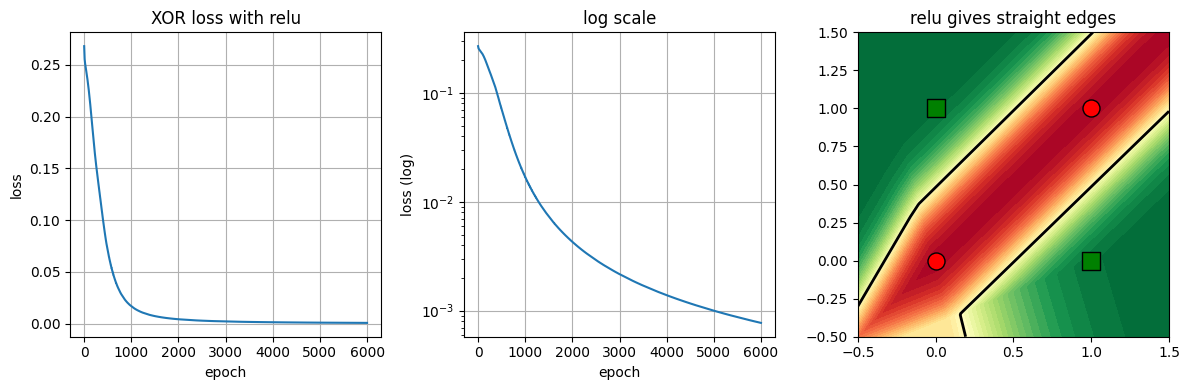

In [6]:
plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
plt.plot(history); plt.xlabel("epoch"); plt.ylabel("loss")
plt.title("XOR loss with relu"); plt.grid(True)
plt.subplot(1,3,2)
plt.plot(history); plt.yscale("log")
plt.xlabel("epoch"); plt.ylabel("loss (log)"); plt.title("log scale"); plt.grid(True)
plt.subplot(1,3,3)
xx, yy = np.meshgrid(np.linspace(-0.5,1.5,250), np.linspace(-0.5,1.5,250))
_, out = forward(net, np.c_[xx.ravel(), yy.ravel()])
plt.contourf(xx, yy, out.reshape(xx.shape), levels=40, cmap='RdYlGn')
plt.contour(xx, yy, out.reshape(xx.shape), levels=[0.5], colors='black', linewidths=2)
for cls, mk, col in [(0,'o','red'), (1,'s','green')]:
    pts = X[y_xor == cls]
    plt.scatter(pts[:,0], pts[:,1], marker=mk, s=150, c=col, edgecolors='black')
plt.title("relu gives straight edges")
plt.tight_layout()
plt.show()

In [7]:
def count_dead(net, X):
    A1, _ = forward(net, X)
    return int(np.sum(np.all(A1 <= 0, axis=0)))
rows = []
for seed in range(20):
    n, h = train_network(X, y_xor, n_hidden=4, seed=seed)
    _, out = forward(n, X)
    acc = ((out.ravel() > 0.5).astype(int) == y_xor).mean()
    rows.append([seed, acc, count_dead(n, X), h[-1]])
solved = sum(1 for r in rows if r[1] == 1.0)
print("seed   accuracy   dead neurons   final loss")
for r in rows:
    flag = "" if r[1] == 1.0 else "   <- failed"
    print(str(r[0]).rjust(4), str(r[1]).rjust(10), str(r[2]).rjust(14), str(round(r[3],5)).rjust(12), flag)
print()
print("solved XOR in", solved, "runs out of 20")
ok_dead = [r[2] for r in rows if r[1] == 1.0]
bad_dead = [r[2] for r in rows if r[1] != 1.0]
print("average dead neurons in the runs that succeeded :", round(np.mean(ok_dead), 2))
print("average dead neurons in the runs that failed    :", round(np.mean(bad_dead), 2))

seed   accuracy   dead neurons   final loss
   0        1.0              0       0.0007 
   1        1.0              0      0.00102 
   2        1.0              1      0.00155 
   3        1.0              1      0.00137 
   4        1.0              0      0.00114 
   5       0.75              2      0.16674    <- failed
   6        1.0              0      0.00077 
   7       0.75              1      0.12525    <- failed
   8       0.75              3      0.16676    <- failed
   9        1.0              1      0.00112 
  10        1.0              2      0.00188 
  11        1.0              0      0.00077 
  12        1.0              0      0.00101 
  13        1.0              0      0.00086 
  14        1.0              1      0.00052 
  15        1.0              0      0.00052 
  16       0.75              0         0.25    <- failed
  17        1.0              1      0.00129 
  18        1.0              0      0.00152 
  19        1.0              1      0.00103 

solved 

hidden units  2 : solved  9 of 20 runs, average dead neurons 0.35
hidden units  4 : solved 16 of 20 runs, average dead neurons 0.7
hidden units  8 : solved 19 of 20 runs, average dead neurons 0.95
hidden units 16 : solved 20 of 20 runs, average dead neurons 3.1


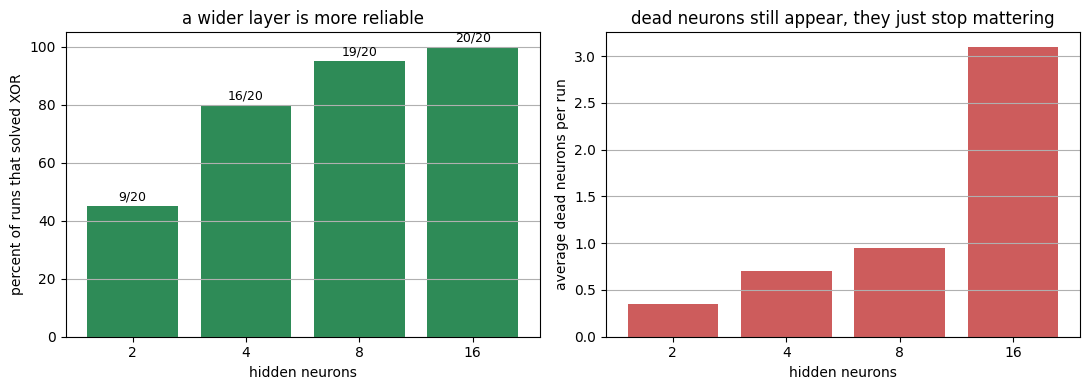

In [8]:
width_rows = []
for h in [2, 4, 8, 16]:
    solved = 0
    dead_total = 0
    for seed in range(20):
        n, _ = train_network(X, y_xor, n_hidden=h, seed=seed)
        _, out = forward(n, X)
        if ((out.ravel() > 0.5).astype(int) == y_xor).mean() == 1.0:
            solved += 1
        dead_total += count_dead(n, X)
    width_rows.append([h, solved, dead_total/20])
    print("hidden units", str(h).rjust(2), ": solved", str(solved).rjust(2), "of 20 runs,",
          "average dead neurons", round(dead_total/20, 2))
plt.figure(figsize=(11,4))
plt.subplot(1,2,1)
plt.bar([str(r[0]) for r in width_rows], [r[1]/20*100 for r in width_rows], color='seagreen')
plt.xlabel("hidden neurons"); plt.ylabel("percent of runs that solved XOR")
plt.title("a wider layer is more reliable"); plt.ylim(0,105); plt.grid(axis='y')
for i, r in enumerate(width_rows):
    plt.text(i, r[1]/20*100 + 2, str(r[1]) + "/20", ha='center', fontsize=9)
plt.subplot(1,2,2)
plt.bar([str(r[0]) for r in width_rows], [r[2] for r in width_rows], color='indianred')
plt.xlabel("hidden neurons"); plt.ylabel("average dead neurons per run")
plt.title("dead neurons still appear, they just stop mattering"); plt.grid(axis='y')
plt.tight_layout()
plt.show()

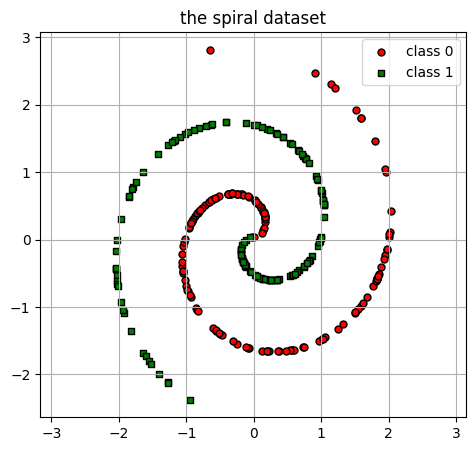

training samples : 280  testing samples : 120


In [9]:
def make_spiral(n=200, noise=0.25, seed=1):
    rng = np.random.default_rng(seed)
    parts_X, parts_y = [], []
    for cls in range(2):
        t = np.linspace(0.3, 3.2, n) + rng.normal(0, noise, n)
        angle = t*2.2 + cls*np.pi
        parts_X.append(np.c_[t*np.cos(angle), t*np.sin(angle)])
        parts_y.append(np.full(n, cls))
    return np.vstack(parts_X), np.concatenate(parts_y)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
Xs, ys = make_spiral()
X_train, X_test, y_train, y_test = train_test_split(Xs, ys, test_size=0.3,
                                                    random_state=5, stratify=ys)
scaler = StandardScaler().fit(X_train)
X_train = scaler.transform(X_train); X_test = scaler.transform(X_test)
plt.figure(figsize=(5.5,5))
plt.scatter(X_train[y_train==0][:,0], X_train[y_train==0][:,1], c='red', marker='o', edgecolors='k', s=25, label="class 0")
plt.scatter(X_train[y_train==1][:,0], X_train[y_train==1][:,1], c='green', marker='s', edgecolors='k', s=25, label="class 1")
plt.title("the spiral dataset"); plt.legend(); plt.grid(True); plt.axis('equal')
plt.show()
print("training samples :", len(X_train), " testing samples :", len(X_test))

In [10]:
def train_bce(X, y, n_hidden=16, lr=0.3, epochs=4000, seed=9):
    net = init_network(X.shape[1], n_hidden, seed=seed)
    Y = y.reshape(-1,1); m = len(y); history = []
    for e in range(epochs):
        A1, A2 = forward(net, X)
        eps = 1e-9
        history.append(-np.mean(Y*np.log(A2+eps) + (1-Y)*np.log(1-A2+eps)))
        d2 = (A2 - Y) / m
        d1 = (d2 @ net["W2"].T) * relu_derivative(A1)
        net["W2"] = net["W2"] - lr * (A1.T @ d2)
        net["b2"] = net["b2"] - lr * d2.sum(axis=0)
        net["W1"] = net["W1"] - lr * (X.T @ d1)
        net["b1"] = net["b1"] - lr * d1.sum(axis=0)
    return net, history
def accuracy(net, X, y):
    _, out = forward(net, X)
    return ((out.ravel() > 0.5).astype(int) == y).mean()
def train_single_bce(X, y, lr=0.5, epochs=3000, seed=4):
    rng = np.random.default_rng(seed)
    w = rng.normal(0, 0.5, X.shape[1]); b = 0.0
    for e in range(epochs):
        a = sigmoid(X @ w + b); d = (a - y) / len(y)
        w = w - lr * (X.T @ d); b = b - lr * d.sum()
    return w, b
net_s, hist_s = train_bce(X_train, y_train)
w_s, b_s = train_single_bce(X_train, y_train)
print("single neuron   ->  train", round(((sigmoid(X_train@w_s+b_s)>0.5)==y_train).mean(),4),
      " test", round(((sigmoid(X_test@w_s+b_s)>0.5)==y_test).mean(),4))
print("relu net of 16  ->  train", round(accuracy(net_s, X_train, y_train),4),
      " test", round(accuracy(net_s, X_test, y_test),4))

single neuron   ->  train 0.4679  test 0.5333
relu net of 16  ->  train 0.9964  test 0.9917


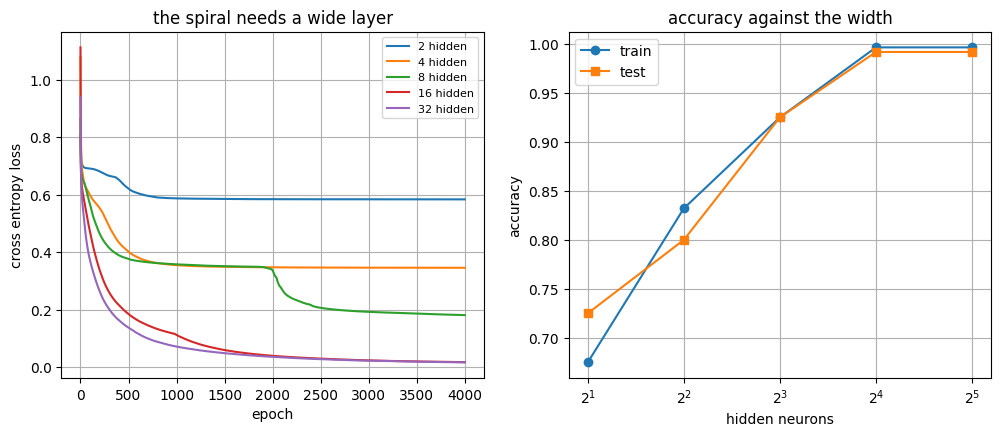

hidden   train acc   test acc   final loss
    2       0.675      0.725       0.5839
    4      0.8321        0.8       0.3459
    8       0.925      0.925       0.1812
   16      0.9964     0.9917       0.0176
   32      0.9964     0.9917       0.0167


In [11]:
results = []
plt.figure(figsize=(12,4.5))
plt.subplot(1,2,1)
for h in [2, 4, 8, 16, 32]:
    n_h, hist_h = train_bce(X_train, y_train, n_hidden=h)
    results.append([h, round(accuracy(n_h, X_train, y_train),4), round(accuracy(n_h, X_test, y_test),4), round(hist_h[-1],4)])
    plt.plot(hist_h, label=str(h) + " hidden")
plt.xlabel("epoch"); plt.ylabel("cross entropy loss")
plt.title("the spiral needs a wide layer"); plt.legend(fontsize=8); plt.grid(True)
plt.subplot(1,2,2)
plt.plot([r[0] for r in results], [r[1] for r in results], 'o-', label="train")
plt.plot([r[0] for r in results], [r[2] for r in results], 's-', label="test")
plt.xscale("log", base=2)
plt.xlabel("hidden neurons"); plt.ylabel("accuracy")
plt.title("accuracy against the width"); plt.legend(); plt.grid(True)
plt.show()
print("hidden   train acc   test acc   final loss")
for r in results:
    print(str(r[0]).rjust(5), str(r[1]).rjust(11), str(r[2]).rjust(10), str(r[3]).rjust(12))

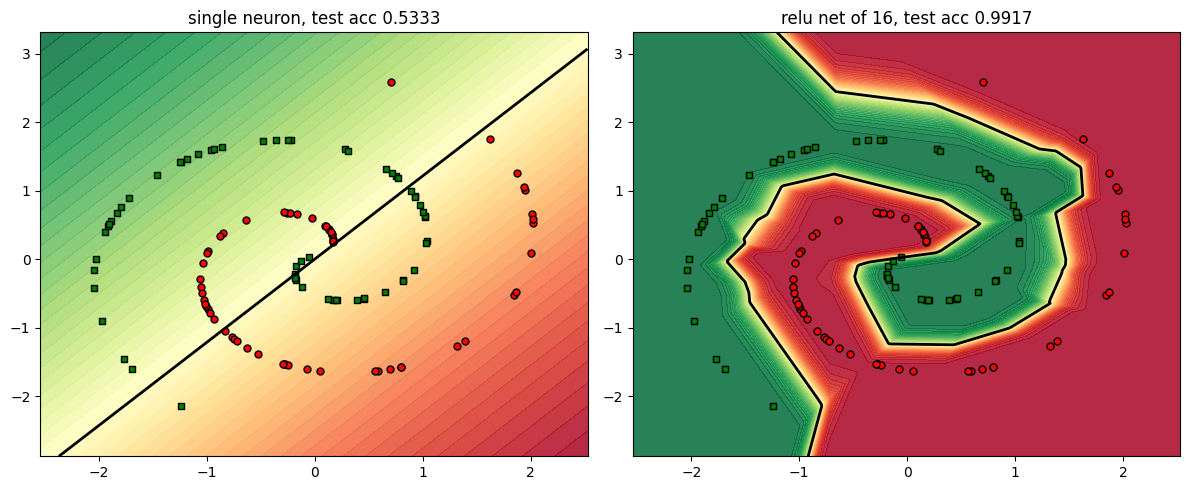

In [12]:
xx, yy = np.meshgrid(np.linspace(X_train[:,0].min()-0.5, X_train[:,0].max()+0.5, 300),
                     np.linspace(X_train[:,1].min()-0.5, X_train[:,1].max()+0.5, 300))
grid = np.c_[xx.ravel(), yy.ravel()]
out_single = sigmoid(grid @ w_s + b_s).reshape(xx.shape)
_, out_net = forward(net_s, grid); out_net = out_net.reshape(xx.shape)
plt.figure(figsize=(12,5))
for i,(title, out) in enumerate([("single neuron, test acc " + str(round(((sigmoid(X_test@w_s+b_s)>0.5)==y_test).mean(),4)), out_single),
                                 ("relu net of 16, test acc " + str(round(accuracy(net_s, X_test, y_test),4)), out_net)]):
    plt.subplot(1,2,i+1)
    plt.contourf(xx, yy, out, levels=50, cmap='RdYlGn', alpha=0.85)
    plt.contour(xx, yy, out, levels=[0.5], colors='black', linewidths=2)
    plt.scatter(X_test[y_test==0][:,0], X_test[y_test==0][:,1], c='red', marker='o', edgecolors='k', s=25)
    plt.scatter(X_test[y_test==1][:,0], X_test[y_test==1][:,1], c='green', marker='s', edgecolors='k', s=25)
    plt.title(title)
plt.tight_layout()
plt.show()

In [13]:
from sklearn.neural_network import MLPClassifier
import warnings
warnings.filterwarnings("ignore")
sk = MLPClassifier(hidden_layer_sizes=(16,), activation='relu', solver='adam',
                   max_iter=4000, random_state=5).fit(X_train, y_train)
print("                 train acc   test acc")
print("my network    :", round(accuracy(net_s, X_train, y_train),4), "    ", round(accuracy(net_s, X_test, y_test),4))
print("sklearn MLP   :", round(sk.score(X_train, y_train),4), "    ", round(sk.score(X_test, y_test),4))
print()
print("sklearn used", sk.n_iter_, "iterations")

                 train acc   test acc
my network    : 0.9964      0.9917
sklearn MLP   : 0.9571      0.9667

sklearn used 1819 iterations


# AISR LAB EXPERIMENT 7
##Comparison of various Learning Strategies for an MLP Classifier

---



**Name:** Sakshi Bhatt  <br>
**SAP ID:** 500121811 <br>
**Batch:** B8 <br>
**Course:** Algorithms for Intelligent Systems and Robotics Lab

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import time
import warnings
warnings.filterwarnings("ignore")
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import confusion_matrix, classification_report
data = load_wine()
X, y = data.data, data.target
HIDDEN = (20,)
print("samples  :", X.shape[0])
print("features :", X.shape[1])
print("classes  :", np.unique(y), " counts :", np.bincount(y))

samples  : 178
features : 13
classes  : [0 1 2]  counts : [59 71 48]


feature names :
    alcohol
    malic_acid
    ash
    alcalinity_of_ash
    magnesium
    total_phenols
    flavanoids
    nonflavanoid_phenols
target names : ['class_0' 'class_1' 'class_2']


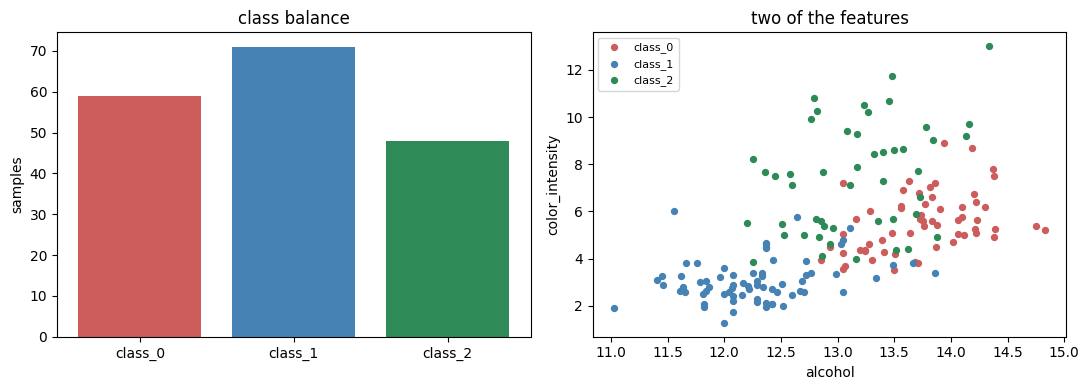

In [15]:
print("feature names :")
for n in data.feature_names[:8]:
    print("   ", n)
print("target names :", data.target_names)
plt.figure(figsize=(11,4))
plt.subplot(1,2,1)
plt.bar(data.target_names, np.bincount(y), color=['indianred','steelblue','seagreen'])
plt.ylabel("samples"); plt.title("class balance")
plt.subplot(1,2,2)
for cls, col in zip(range(3), ['indianred','steelblue','seagreen']):
    plt.scatter(X[y==cls][:,0], X[y==cls][:,9], c=col, s=18, label=data.target_names[cls])
plt.xlabel(data.feature_names[0]); plt.ylabel(data.feature_names[9])
plt.title("two of the features"); plt.legend(fontsize=8)
plt.tight_layout(); plt.show()

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y)
scaler = StandardScaler().fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)
print("training samples :", X_train.shape[0])
print("testing samples  :", X_test.shape[0])
print("one test sample is worth", round(100/len(y_test), 2), "percent of the test accuracy")

training samples : 133
testing samples  : 45
one test sample is worth 2.22 percent of the test accuracy


In [17]:
def run_mlp(name, **params):
    settings = dict(hidden_layer_sizes=HIDDEN, max_iter=400, random_state=42)
    settings.update(params)
    start = time.time()
    model = MLPClassifier(**settings).fit(X_train, y_train)
    took = time.time() - start
    return {"name": name, "model": model,
            "train": model.score(X_train, y_train),
            "test": model.score(X_test, y_test),
            "iters": model.n_iter_, "time": took}
def show_table(rows, title):
    print(title)
    print()
    print("strategy".ljust(20), "train".rjust(8), "test".rjust(8), "iters".rjust(7), "time(s)".rjust(9))
    print("-" * 56)
    for r in rows:
        print(r["name"].ljust(20), str(round(r["train"],4)).rjust(8), str(round(r["test"],4)).rjust(8),
              str(r["iters"]).rjust(7), str(round(r["time"],2)).rjust(9))

In [18]:
solver_settings = [
    ["adam",            dict(solver='adam', learning_rate_init=0.001)],
    ["sgd constant",    dict(solver='sgd', learning_rate='constant', learning_rate_init=0.01,
                             momentum=0, nesterovs_momentum=False)],
    ["sgd momentum",    dict(solver='sgd', learning_rate='constant', learning_rate_init=0.01,
                             momentum=0.9, nesterovs_momentum=False)],
    ["sgd nesterov",    dict(solver='sgd', learning_rate='constant', learning_rate_init=0.01,
                             momentum=0.9, nesterovs_momentum=True)],
    ["sgd invscaling",  dict(solver='sgd', learning_rate='invscaling', learning_rate_init=0.05,
                             momentum=0.9)],
    ["sgd adaptive",    dict(solver='sgd', learning_rate='adaptive', learning_rate_init=0.01,
                             momentum=0.9)],
    ["lbfgs",           dict(solver='lbfgs')],
]
solver_results = [run_mlp(n, **kw) for n, kw in solver_settings]
show_table(solver_results, "comparison of the solvers")

comparison of the solvers

strategy                train     test   iters   time(s)
--------------------------------------------------------
adam                   0.9925      1.0     400      0.24
sgd constant            0.985   0.9778     400      0.25
sgd momentum              1.0   0.9778     231      0.15
sgd nesterov              1.0   0.9778     232      0.16
sgd invscaling         0.9248   0.9778     400      0.28
sgd adaptive              1.0   0.9778     298       0.2
lbfgs                     1.0   0.9333      12      0.05


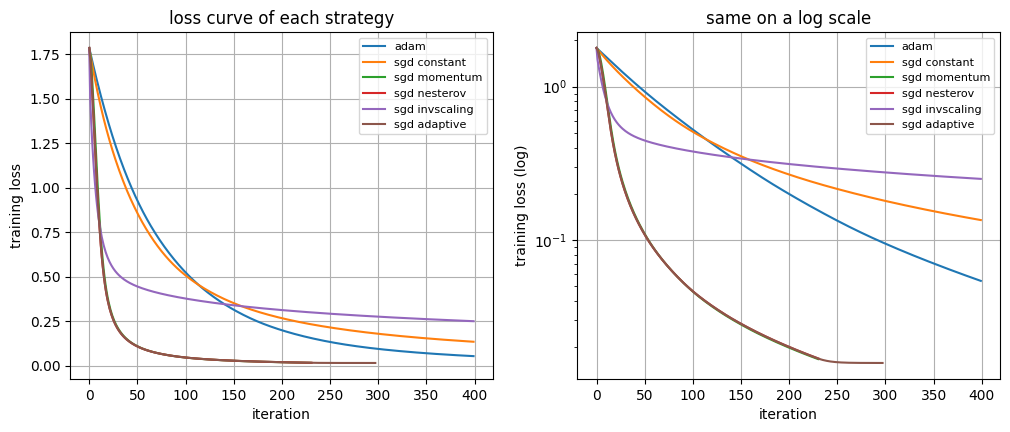

lbfgs is not in the plot, sklearn does not store a loss curve for it


In [19]:
plt.figure(figsize=(12,4.5))
plt.subplot(1,2,1)
for r in solver_results:
    if hasattr(r["model"], "loss_curve_"):
        plt.plot(r["model"].loss_curve_, label=r["name"])
plt.xlabel("iteration"); plt.ylabel("training loss")
plt.title("loss curve of each strategy"); plt.legend(fontsize=8); plt.grid(True)
plt.subplot(1,2,2)
for r in solver_results:
    if hasattr(r["model"], "loss_curve_"):
        plt.plot(r["model"].loss_curve_, label=r["name"])
plt.yscale("log")
plt.xlabel("iteration"); plt.ylabel("training loss (log)")
plt.title("same on a log scale"); plt.legend(fontsize=8); plt.grid(True)
plt.show()
print("lbfgs is not in the plot, sklearn does not store a loss curve for it")

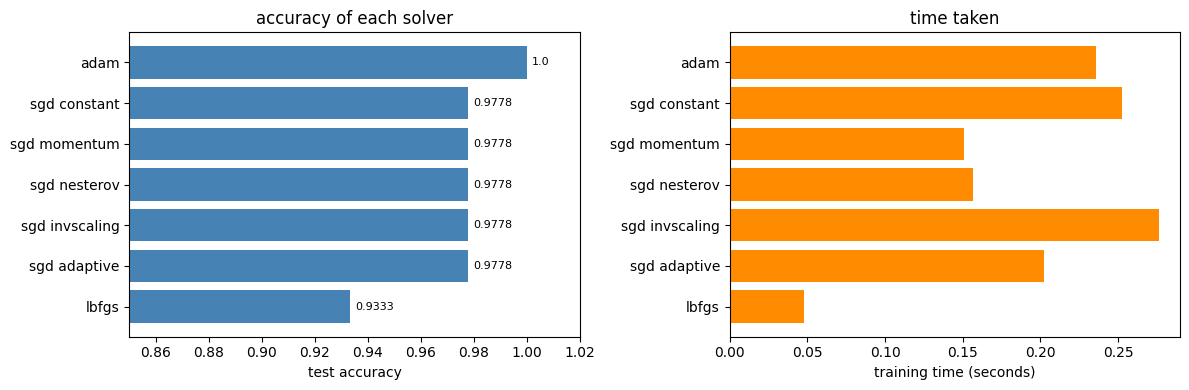

In [20]:
names = [r["name"] for r in solver_results]
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.barh(names[::-1], [r["test"] for r in solver_results][::-1], color='steelblue')
plt.xlim(0.85, 1.02); plt.xlabel("test accuracy"); plt.title("accuracy of each solver")
for i, r in enumerate(solver_results[::-1]):
    plt.text(r["test"]+0.002, i, str(round(r["test"],4)), va='center', fontsize=8)
plt.subplot(1,2,2)
plt.barh(names[::-1], [r["time"] for r in solver_results][::-1], color='darkorange')
plt.xlabel("training time (seconds)"); plt.title("time taken")
plt.tight_layout(); plt.show()

In [21]:
lr_results = []
for lr in [0.0001, 0.001, 0.01, 0.1, 1.0]:
    r = run_mlp("lr = " + str(lr), solver='sgd', learning_rate_init=lr, momentum=0.9)
    r["lr"] = lr; r["final_loss"] = r["model"].loss_
    lr_results.append(r)
show_table(lr_results, "effect of the learning rate")
print()
for r in lr_results:
    print(r["name"].ljust(12), "final training loss :", round(r["final_loss"], 4))

effect of the learning rate

strategy                train     test   iters   time(s)
--------------------------------------------------------
lr = 0.0001            0.4211   0.4889     400      0.18
lr = 0.001              0.985   0.9778     400      0.18
lr = 0.01                 1.0   0.9778     232       0.1
lr = 0.1                  1.0   0.9778      53      0.02
lr = 1.0                  1.0   0.9556      24      0.01

lr = 0.0001  final training loss : 0.9832
lr = 0.001   final training loss : 0.1363
lr = 0.01    final training loss : 0.0169
lr = 0.1     final training loss : 0.002
lr = 1.0     final training loss : 0.0001


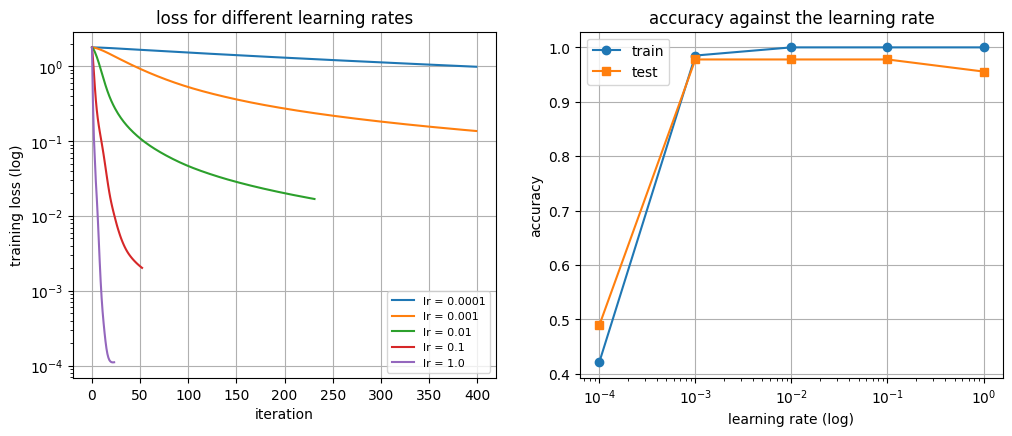

In [22]:
plt.figure(figsize=(12,4.5))
plt.subplot(1,2,1)
for r in lr_results:
    plt.plot(r["model"].loss_curve_, label=r["name"])
plt.yscale("log"); plt.xlabel("iteration"); plt.ylabel("training loss (log)")
plt.title("loss for different learning rates"); plt.legend(fontsize=8); plt.grid(True)
plt.subplot(1,2,2)
plt.semilogx([r["lr"] for r in lr_results], [r["train"] for r in lr_results], 'o-', label="train")
plt.semilogx([r["lr"] for r in lr_results], [r["test"] for r in lr_results], 's-', label="test")
plt.xlabel("learning rate (log)"); plt.ylabel("accuracy")
plt.title("accuracy against the learning rate"); plt.legend(); plt.grid(True)
plt.show()

In [23]:
act_results = [run_mlp(a, solver='adam', activation=a)
               for a in ['relu', 'tanh', 'logistic', 'identity']]
show_table(act_results, "effect of the activation function")

effect of the activation function

strategy                train     test   iters   time(s)
--------------------------------------------------------
relu                   0.9925      1.0     400      0.21
tanh                      1.0   0.9556     400      0.29
logistic               0.9925      1.0     400      0.29
identity                  1.0   0.9556     400      0.21


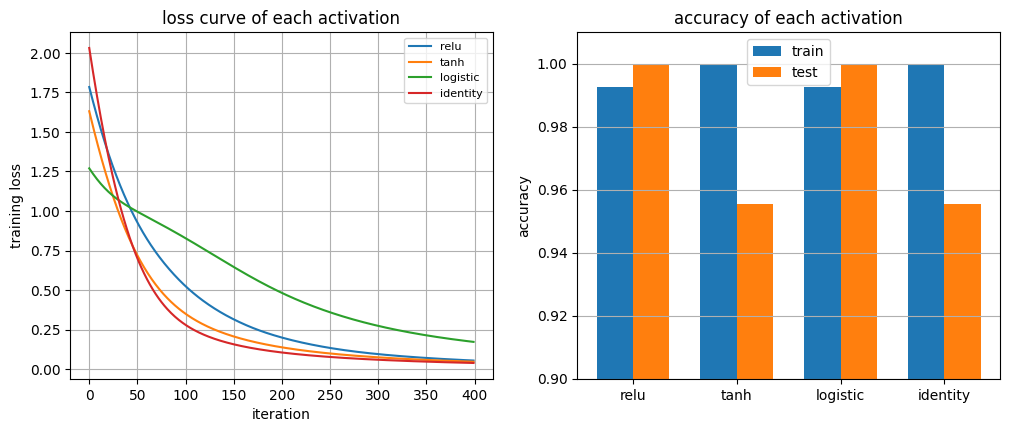

In [24]:
plt.figure(figsize=(12,4.5))
plt.subplot(1,2,1)
for r in act_results:
    plt.plot(r["model"].loss_curve_, label=r["name"])
plt.xlabel("iteration"); plt.ylabel("training loss")
plt.title("loss curve of each activation"); plt.legend(fontsize=8); plt.grid(True)
plt.subplot(1,2,2)
x = np.arange(len(act_results)); w = 0.35
plt.bar(x-w/2, [r["train"] for r in act_results], w, label="train")
plt.bar(x+w/2, [r["test"] for r in act_results], w, label="test")
plt.xticks(x, [r["name"] for r in act_results]); plt.ylim(0.9, 1.01)
plt.ylabel("accuracy"); plt.title("accuracy of each activation")
plt.legend(); plt.grid(axis='y')
plt.show()

In [25]:
ARCHS = [(5,), (10,), (20,), (20,20), (40,20,10)]
arch_results = [run_mlp(str(h), solver='adam', hidden_layer_sizes=h) for h in ARCHS]
show_table(arch_results, "effect of the architecture")
print()
n_feat, n_cls = X.shape[1], len(np.unique(y))
for h in ARCHS:
    total = n_feat*h[0] + h[0]
    for i in range(len(h)-1):
        total += h[i]*h[i+1] + h[i+1]
    total += h[-1]*n_cls + n_cls
    print(str(h).ljust(14), "has about", total, "parameters")

effect of the architecture

strategy                train     test   iters   time(s)
--------------------------------------------------------
(5,)                   0.9699   0.9333     400       0.3
(10,)                  0.9925   0.9556     400      0.21
(20,)                  0.9925      1.0     400       0.2
(20, 20)                  1.0      1.0     292      0.23
(40, 20, 10)              1.0   0.9778     222      0.25

(5,)           has about 88 parameters
(10,)          has about 173 parameters
(20,)          has about 343 parameters
(20, 20)       has about 763 parameters
(40, 20, 10)   has about 1623 parameters


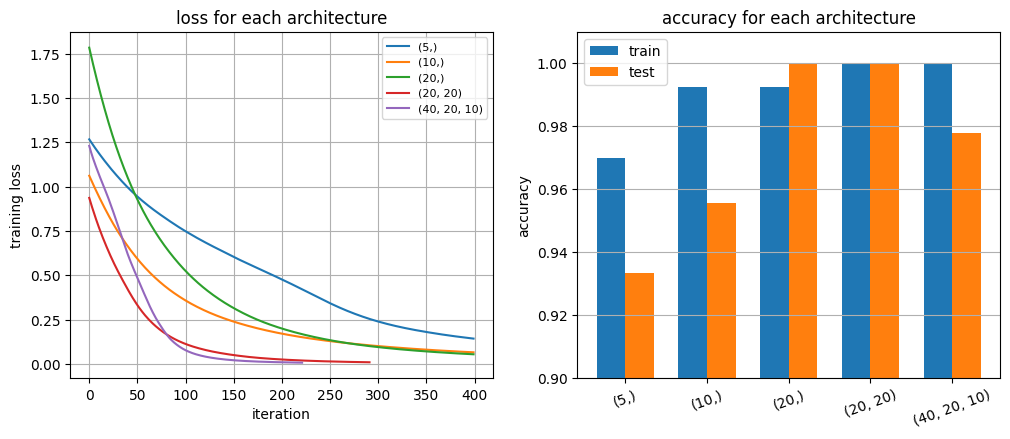

In [26]:
plt.figure(figsize=(12,4.5))
plt.subplot(1,2,1)
for r in arch_results:
    plt.plot(r["model"].loss_curve_, label=r["name"])
plt.xlabel("iteration"); plt.ylabel("training loss")
plt.title("loss for each architecture"); plt.legend(fontsize=8); plt.grid(True)
plt.subplot(1,2,2)
x = np.arange(len(arch_results)); w = 0.35
plt.bar(x-w/2, [r["train"] for r in arch_results], w, label="train")
plt.bar(x+w/2, [r["test"] for r in arch_results], w, label="test")
plt.xticks(x, [r["name"] for r in arch_results], rotation=20); plt.ylim(0.9, 1.01)
plt.ylabel("accuracy"); plt.title("accuracy for each architecture")
plt.legend(); plt.grid(axis='y')
plt.show()

In [27]:
batch_results = [run_mlp("batch " + str(b), solver='adam', batch_size=b)
                 for b in [8, 32, 128, 'auto']]
show_table(batch_results, "effect of the batch size")

effect of the batch size

strategy                train     test   iters   time(s)
--------------------------------------------------------
batch 8                   1.0   0.9778     134      0.88
batch 32                  1.0   0.9778     268      0.66
batch 128                 1.0   0.9778     400      0.32
batch auto             0.9925      1.0     400       0.2


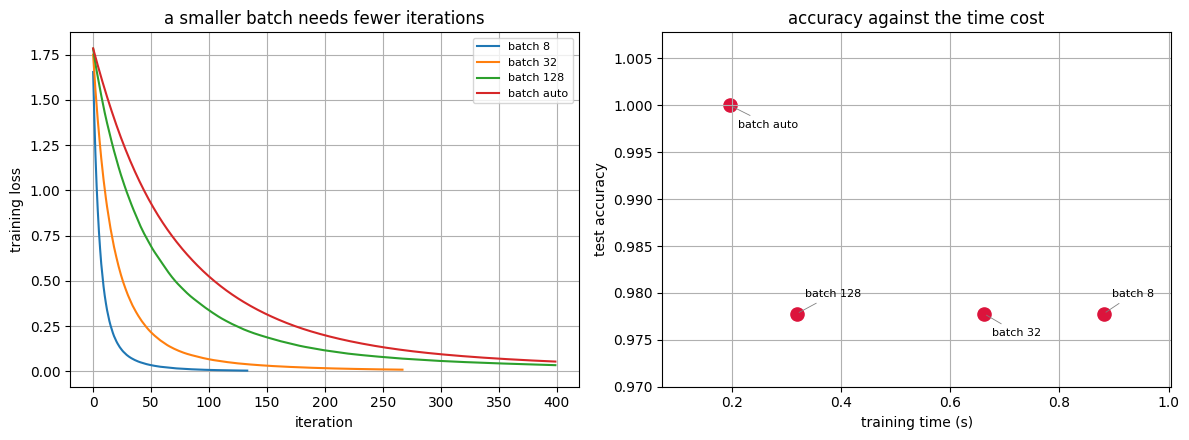

test accuracies obtained : [0.9778, 1.0]


In [28]:
plt.figure(figsize=(12,4.5))
plt.subplot(1,2,1)
for r in batch_results:
    plt.plot(r["model"].loss_curve_, label=r["name"])
plt.xlabel("iteration"); plt.ylabel("training loss")
plt.title("a smaller batch needs fewer iterations"); plt.legend(fontsize=8); plt.grid(True)
plt.subplot(1,2,2)
plt.scatter([r["time"] for r in batch_results], [r["test"] for r in batch_results], s=90, c='crimson')
# the points can share the same accuracy, so the labels are staggered to keep them readable
for i, r in enumerate(batch_results):
    dy = 12 if i % 2 == 0 else -16
    plt.annotate(r["name"], (r["time"], r["test"]), textcoords="offset points",
                 xytext=(6, dy), fontsize=8,
                 arrowprops=dict(arrowstyle='-', color='gray', linewidth=0.6))
plt.xlabel("training time (s)"); plt.ylabel("test accuracy")
plt.title("accuracy against the time cost")
plt.margins(x=0.18, y=0.35)
plt.grid(True)
plt.tight_layout(); plt.show()
accs = sorted(set(round(r["test"], 4) for r in batch_results))
if len(accs) == 1:
    print("every batch size gave the same test accuracy of", accs[0],
          ", so the batch size only changed the training time here")
else:
    print("test accuracies obtained :", accs)

In [29]:
alpha_values = [1e-6, 1e-3, 1e-1, 1.0, 10.0]
alpha_results = [run_mlp("alpha " + str(a), solver='adam', alpha=a) for a in alpha_values]
show_table(alpha_results, "effect of the regularisation")

effect of the regularisation

strategy                train     test   iters   time(s)
--------------------------------------------------------
alpha 1e-06            0.9925      1.0     400      0.25
alpha 0.001            0.9925      1.0     400       0.3
alpha 0.1              0.9925      1.0     400      0.35
alpha 1.0              0.9925      1.0     400      0.36
alpha 10.0             0.9925   0.9778     400      0.35


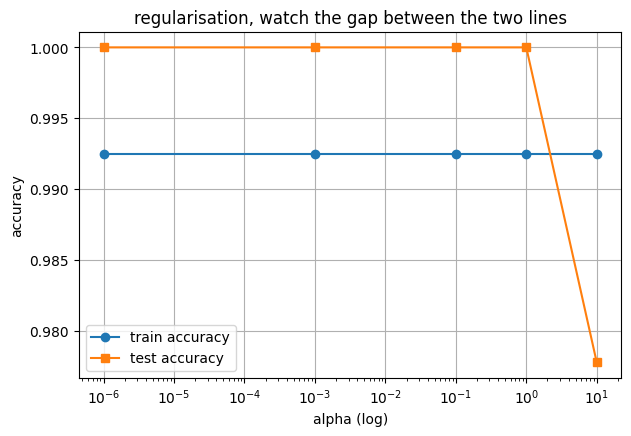

In [30]:
plt.figure(figsize=(7,4.5))
plt.semilogx(alpha_values, [r["train"] for r in alpha_results], 'o-', label="train accuracy")
plt.semilogx(alpha_values, [r["test"] for r in alpha_results], 's-', label="test accuracy")
plt.xlabel("alpha (log)"); plt.ylabel("accuracy")
plt.title("regularisation, watch the gap between the two lines")
plt.legend(); plt.grid(True)
plt.show()

In [31]:
baseline = run_mlp("baseline (default)", solver='adam')
tuned = run_mlp("tuned", hidden_layer_sizes=(20,), activation='relu', solver='adam', alpha=0.1, learning_rate_init=0.01, max_iter=600)
show_table([baseline, tuned], "baseline against the tuned model")
y_pred = tuned["model"].predict(X_test)
print()
print("baseline mistakes :", (baseline["model"].predict(X_test) != y_test).sum(), "of", len(y_test))
print("tuned mistakes    :", (y_pred != y_test).sum(), "of", len(y_test))

baseline against the tuned model

strategy                train     test   iters   time(s)
--------------------------------------------------------
baseline (default)     0.9925      1.0     400      0.21
tuned                     1.0   0.9778     117      0.06

baseline mistakes : 0 of 45
tuned mistakes    : 1 of 45


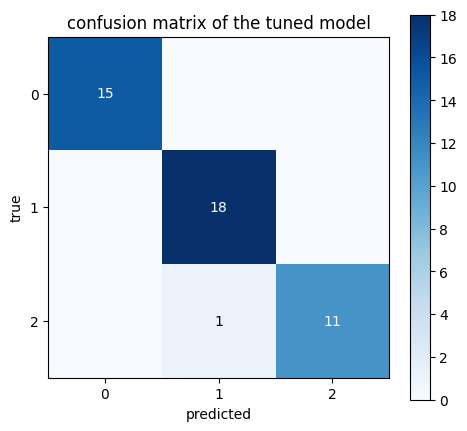

              precision    recall  f1-score   support

           0      1.000     1.000     1.000        15
           1      0.947     1.000     0.973        18
           2      1.000     0.917     0.957        12

    accuracy                          0.978        45
   macro avg      0.982     0.972     0.976        45
weighted avg      0.979     0.978     0.978        45



In [32]:
cm = confusion_matrix(y_test, y_pred)
n_cls = cm.shape[0]
plt.figure(figsize=(5.5,5))
plt.imshow(cm, cmap='Blues')
plt.colorbar()
for i in range(n_cls):
    for j in range(n_cls):
        if cm[i,j] > 0:
            plt.text(j, i, cm[i,j], ha='center', va='center',
                     color='white' if cm[i,j] > cm.max()/2 else 'black')
plt.xlabel("predicted"); plt.ylabel("true")
plt.title("confusion matrix of the tuned model")
plt.xticks(range(n_cls)); plt.yticks(range(n_cls))
plt.show()
print(classification_report(y_test, y_pred, digits=3))

In [33]:
from sklearn.pipeline import make_pipeline
cv_settings = [
    ["adam default",     dict(solver='adam')],
    ["sgd momentum 0.1", dict(solver='sgd', learning_rate_init=0.1, momentum=0.9)],
    ["lbfgs",            dict(solver='lbfgs')],
    ["tuned",            dict(alpha=0.1, learning_rate_init=0.01)],
]
cv_rows = []
for name, kw in cv_settings:
    settings = dict(hidden_layer_sizes=HIDDEN, max_iter=400, random_state=42)
    settings.update(kw)
    pipe = make_pipeline(StandardScaler(), MLPClassifier(**settings))
    scores = cross_val_score(pipe, X, y, cv=5)
    cv_rows.append([name, scores.mean(), scores.std()])
    print(name.ljust(18), "mean", round(scores.mean(),4), " std", round(scores.std(),4),
          " folds", np.round(scores,3))

adam default       mean 0.9554  std 0.0484  folds [0.861 0.972 0.972 0.971 1.   ]
sgd momentum 0.1   mean 0.9663  std 0.0211  folds [0.972 0.944 0.972 0.943 1.   ]
lbfgs              mean 0.9832  std 0.0137  folds [0.972 0.972 1.    0.971 1.   ]
tuned              mean 0.9665  std 0.0207  folds [0.944 0.972 0.944 1.    0.971]


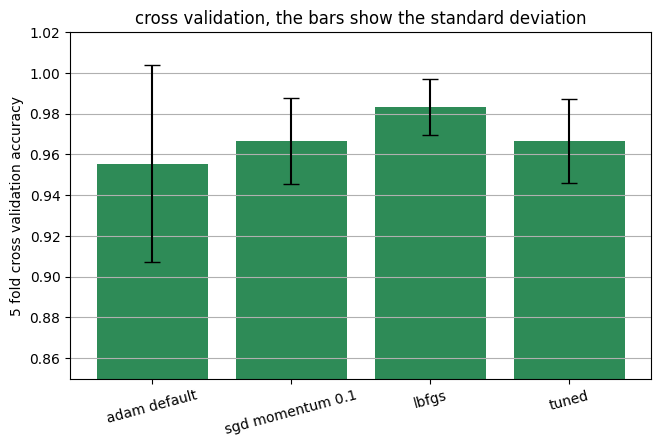

In [34]:
plt.figure(figsize=(7.5,4.5))
plt.bar([r[0] for r in cv_rows], [r[1] for r in cv_rows],
        yerr=[r[2] for r in cv_rows], capsize=6, color='seagreen')
plt.ylabel("5 fold cross validation accuracy")
plt.ylim(0.85, 1.02); plt.xticks(rotation=15)
plt.title("cross validation, the bars show the standard deviation")
plt.grid(axis='y')
plt.show()

# AISR EXPERIMENT 8

---


## Kalman Filtering using Python

---



**Name:** Sakshi Bhatt  <br>
**SAP ID:** 500121811<br>
**Batch:** B8<br>
**Course:** Algorithms for Intelligent Systems and Robotics Lab

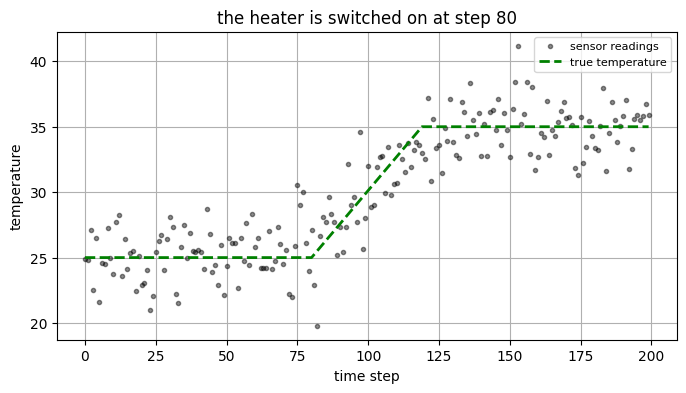

sensor noise std : 2.0 degrees
the temperature is constant for the first 80 steps, then rises for 40 steps


In [35]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(21)
N = 200
R = 4.0                     # sensor noise variance, std is 2 degrees
true_temp = np.concatenate([np.full(80, 25.0),
                            np.linspace(25, 35, 40),
                            np.full(80, 35.0)])
measurements = true_temp + np.random.normal(0, np.sqrt(R), N)
plt.figure(figsize=(8,4))
plt.plot(measurements, 'k.', alpha=0.45, label="sensor readings")
plt.plot(true_temp, 'g--', linewidth=2, label="true temperature")
plt.xlabel("time step"); plt.ylabel("temperature")
plt.title("the heater is switched on at step 80")
plt.legend(fontsize=8); plt.grid(True)
plt.show()
print("sensor noise std :", np.sqrt(R), "degrees")
print("the temperature is constant for the first 80 steps, then rises for 40 steps")

In [36]:
def kalman_1d(measurements, Q, R, x0=20.0, P0=100.0):
    x = x0
    P = P0
    estimates, gains = [], []
    for z in measurements:
        # prediction, the model says nothing changes, so only the doubt grows
        P = P + Q
        # update
        K = P / (P + R)
        x = x + K * (z - x)
        P = (1 - K) * P
        estimates.append(x); gains.append(K)
    return np.array(estimates), np.array(gains)
def rmse(a, b):
    return np.sqrt(np.mean((a - b)**2))
print("       Q     overall RMSE    steady gain    error during the ramp")
rows = []
for Q in [0.001, 0.01, 0.1, 1.0]:
    est, gain = kalman_1d(measurements, Q, R)
    overall = rmse(est, true_temp)
    ramp = rmse(est[80:120], true_temp[80:120])
    rows.append([Q, est, gain, overall, ramp])
    print(str(Q).rjust(8), str(round(overall,4)).rjust(14), str(round(gain[-1],4)).rjust(14), str(round(ramp,4)).rjust(22))
print()
print("raw sensor RMSE :", round(rmse(measurements, true_temp), 4))

       Q     overall RMSE    steady gain    error during the ramp
   0.001         3.3931         0.0157                 4.3781
    0.01         1.7355         0.0488                 2.9417
     0.1         0.9222         0.1461                 1.4658
     1.0         1.0796         0.3904                 1.1379

raw sensor RMSE : 2.0177


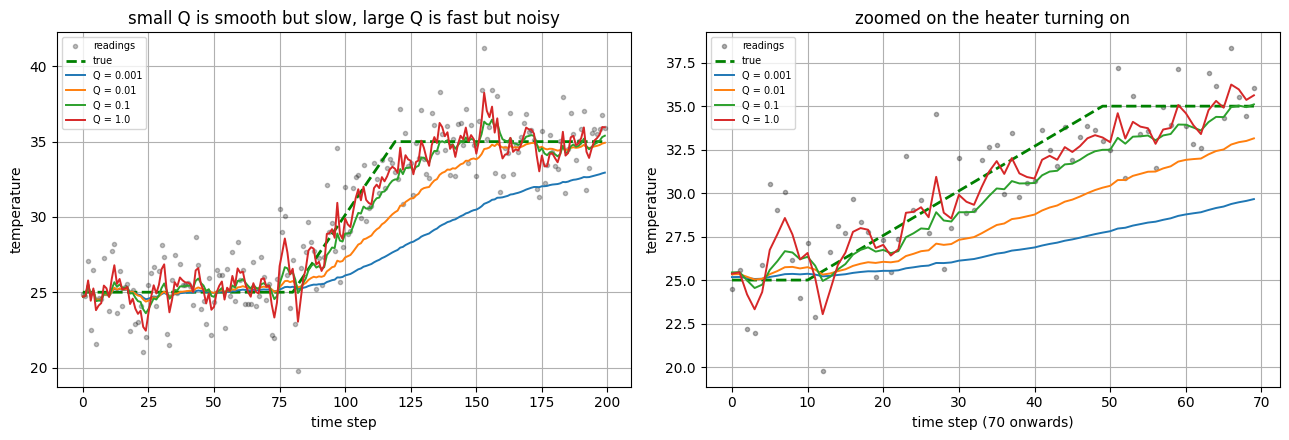

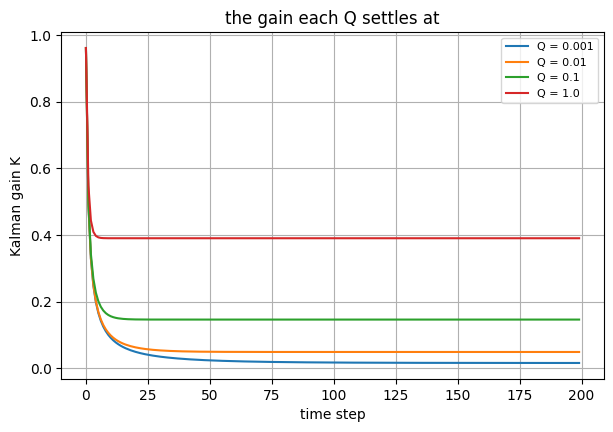

Q = 0.001   steady gain 0.0157  means it accepts 1.6 percent of each new reading
Q = 0.01    steady gain 0.0488  means it accepts 4.9 percent of each new reading
Q = 0.1     steady gain 0.1461  means it accepts 14.6 percent of each new reading
Q = 1.0     steady gain 0.3904  means it accepts 39.0 percent of each new reading


In [37]:
plt.figure(figsize=(13,4.5))
plt.subplot(1,2,1)
plt.plot(measurements, 'k.', alpha=0.25, label="readings")
plt.plot(true_temp, 'g--', linewidth=2, label="true")
for Q, est, gain, overall, ramp in rows:
    plt.plot(est, linewidth=1.4, label="Q = " + str(Q))
plt.xlabel("time step"); plt.ylabel("temperature")
plt.title("small Q is smooth but slow, large Q is fast but noisy")
plt.legend(fontsize=7); plt.grid(True)
plt.subplot(1,2,2)
plt.plot(measurements[70:140], 'k.', alpha=0.3, label="readings")
plt.plot(true_temp[70:140], 'g--', linewidth=2, label="true")
for Q, est, gain, overall, ramp in rows:
    plt.plot(est[70:140], linewidth=1.4, label="Q = " + str(Q))
plt.xlabel("time step (70 onwards)"); plt.ylabel("temperature")
plt.title("zoomed on the heater turning on")
plt.legend(fontsize=7); plt.grid(True)
plt.tight_layout(); plt.show()
plt.figure(figsize=(7,4.5))
for Q, est, gain, overall, ramp in rows:
    plt.plot(gain, label="Q = " + str(Q))
plt.xlabel("time step"); plt.ylabel("Kalman gain K")
plt.title("the gain each Q settles at")
plt.legend(fontsize=8); plt.grid(True)
plt.show()
for Q, est, gain, overall, ramp in rows:
    print("Q =", str(Q).ljust(7), "steady gain", round(gain[-1],4),
          " means it accepts", round(gain[-1]*100,1), "percent of each new reading")

In [38]:
np.random.seed(22)
dt = 0.1
side = 60
speed = 2.0
segments = [(speed, 0), (0, speed), (-speed, 0), (0, -speed)]
true = []
pos = np.array([0.0, 0.0])
for vx, vy in segments:
    for _ in range(side):
        true.append([pos[0], vx, pos[1], vy])
        pos = pos + np.array([vx, vy]) * dt
true = np.array(true)
N2 = len(true)
r_noise = 1.5
meas2d = true[:, [0,2]] + np.random.normal(0, np.sqrt(r_noise), (N2, 2))
F = np.array([[1, dt, 0,  0],
              [0,  1, 0,  0],
              [0,  0, 1, dt],
              [0,  0, 0,  1]])
H = np.array([[1, 0, 0, 0],
              [0, 0, 1, 0]])
corners = [side, 2*side, 3*side]
print("total steps :", N2, " with a corner at steps", corners)
print("side length :", round(side*speed*dt, 1), "units")

total steps : 240  with a corner at steps [60, 120, 180]
side length : 12.0 units


In [39]:
def kalman_2d(measurements, q, r, skip=None):
    Q = q * np.array([[dt**4/4, dt**3/2, 0,       0      ],
                      [dt**3/2, dt**2,   0,       0      ],
                      [0,       0,       dt**4/4, dt**3/2],
                      [0,       0,       dt**3/2, dt**2  ]])
    R = r * np.eye(2)
    x = np.zeros(4); P = np.eye(4) * 500.0
    est = np.zeros((len(measurements), 4))
    p_trace = []
    for k in range(len(measurements)):
        x = F @ x
        P = F @ P @ F.T + Q
        if skip is None or not (skip[0] <= k < skip[1]):
            y = measurements[k] - H @ x
            S = H @ P @ H.T + R
            K = P @ H.T @ np.linalg.inv(S)
            x = x + K @ y
            P = (np.eye(4) - K @ H) @ P
        est[k] = x
        p_trace.append(np.trace(P))
    return est, np.array(p_trace)
def corner_error(est):
    vals = []
    for cpt in corners:
        d = np.linalg.norm(est[cpt:cpt+8][:, [0,2]] - true[cpt:cpt+8][:, [0,2]], axis=1)
        vals.append(d.mean())
    return np.mean(vals)
def straight_error(est):
    d = np.linalg.norm(est[20:50][:, [0,2]] - true[20:50][:, [0,2]], axis=1)
    return d.mean()
print("raw measurement RMSE :", round(rmse(meas2d, true[:, [0,2]]), 4))
print()
print("     q    overall RMSE   error after a corner   error on a straight")
tune_rows = []
for q in [0.05, 0.5, 5.0, 20.0]:
    e, _ = kalman_2d(meas2d, q, r_noise)
    tune_rows.append([q, e, rmse(e[:, [0,2]], true[:, [0,2]]), corner_error(e), straight_error(e)])
    print(str(q).rjust(7), str(round(tune_rows[-1][2],4)).rjust(14),
          str(round(tune_rows[-1][3],4)).rjust(22), str(round(tune_rows[-1][4],4)).rjust(21))

raw measurement RMSE : 1.2845

     q    overall RMSE   error after a corner   error on a straight
   0.05         1.4759                 1.4601                0.7145
    0.5         0.7161                 0.9079                0.6726
    5.0         0.5555                 0.7901                0.6938
   20.0         0.5955                 0.7359                0.7649


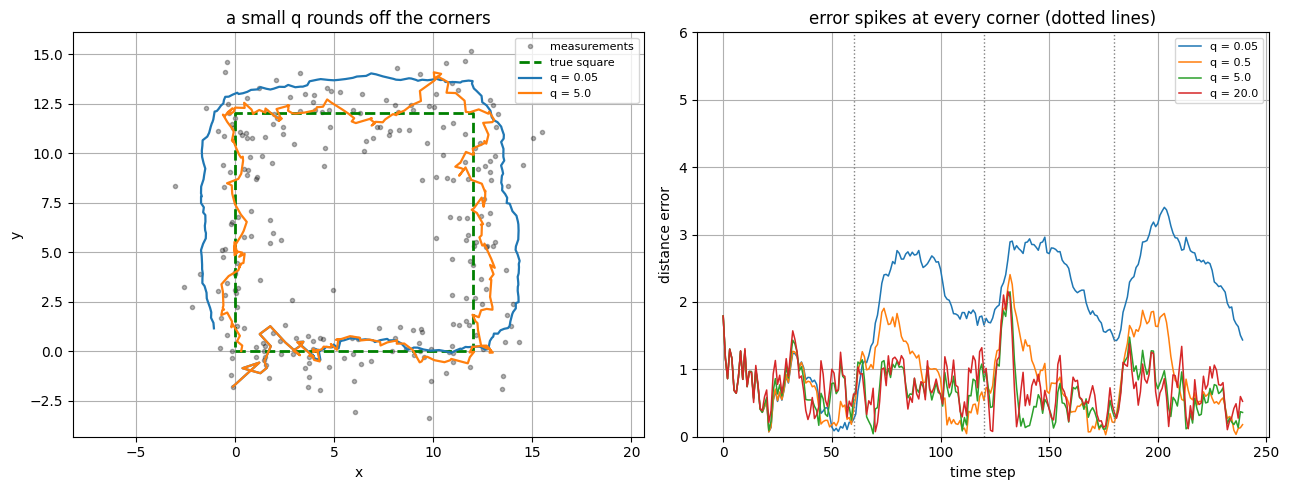

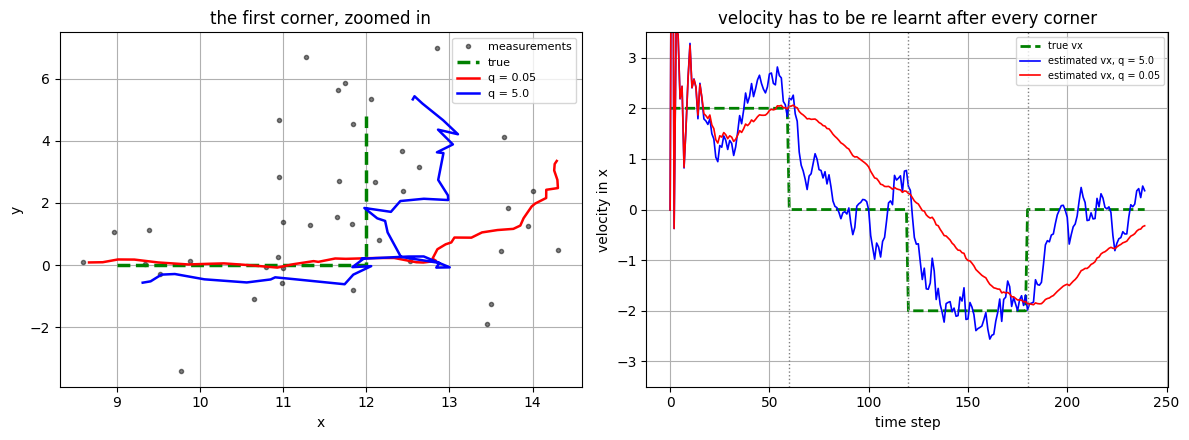

In [40]:
plt.figure(figsize=(13,5))
plt.subplot(1,2,1)
plt.plot(meas2d[:,0], meas2d[:,1], 'k.', alpha=0.3, label="measurements")
plt.plot(true[:,0], true[:,2], 'g--', linewidth=2, label="true square")
for q, e, _, _, _ in [tune_rows[0], tune_rows[2]]:
    plt.plot(e[:,0], e[:,2], linewidth=1.6, label="q = " + str(q))
plt.xlabel("x"); plt.ylabel("y"); plt.axis('equal')
plt.title("a small q rounds off the corners")
plt.legend(fontsize=8); plt.grid(True)
plt.subplot(1,2,2)
for q, e, _, _, _ in tune_rows:
    err = np.linalg.norm(e[:, [0,2]] - true[:, [0,2]], axis=1)
    plt.plot(err, linewidth=1.1, label="q = " + str(q))
for cpt in corners:
    plt.axvline(cpt, color='gray', linestyle=':', linewidth=1)
plt.xlabel("time step"); plt.ylabel("distance error")
plt.title("error spikes at every corner (dotted lines)")
plt.legend(fontsize=8); plt.grid(True); plt.ylim(0, 6)
plt.tight_layout(); plt.show()
# a closer look at the first corner
q_small, e_small = tune_rows[0][0], tune_rows[0][1]
q_big, e_big = tune_rows[2][0], tune_rows[2][1]
plt.figure(figsize=(12,4.5))
plt.subplot(1,2,1)
w = slice(corners[0]-15, corners[0]+25)
plt.plot(meas2d[w,0], meas2d[w,1], 'k.', alpha=0.5, label="measurements")
plt.plot(true[w,0], true[w,2], 'g--', linewidth=2.5, label="true")
plt.plot(e_small[w,0], e_small[w,2], 'r', linewidth=1.8, label="q = " + str(q_small))
plt.plot(e_big[w,0], e_big[w,2], 'b', linewidth=1.8, label="q = " + str(q_big))
plt.xlabel("x"); plt.ylabel("y"); plt.title("the first corner, zoomed in")
plt.legend(fontsize=8); plt.grid(True)
plt.subplot(1,2,2)
plt.plot(true[:,1], 'g--', linewidth=2, label="true vx")
plt.plot(e_big[:,1], 'b', linewidth=1.2, label="estimated vx, q = " + str(q_big))
plt.plot(e_small[:,1], 'r', linewidth=1.2, label="estimated vx, q = " + str(q_small))
for cpt in corners:
    plt.axvline(cpt, color='gray', linestyle=':', linewidth=1)
plt.ylim(-3.5, 3.5)
plt.xlabel("time step"); plt.ylabel("velocity in x")
plt.title("velocity has to be re learnt after every corner")
plt.legend(fontsize=7); plt.grid(True)
plt.tight_layout(); plt.show()

In [41]:
best_q = 0.5
est_ok, _ = kalman_2d(meas2d, best_q, r_noise)
est_fail, _ = kalman_2d(meas2d, best_q, r_noise, skip=(150, 190))
print("RMSE with the sensor working  :", round(rmse(est_ok[:, [0,2]], true[:, [0,2]]), 4))
print("RMSE with the sensor dead     :", round(rmse(est_fail[:, [0,2]], true[:, [0,2]]), 4))
print()
print("during the blackout, steps 150 to 190")
print("   with measurements :", round(rmse(est_ok[150:190][:, [0,2]], true[150:190][:, [0,2]]), 4))
print("   prediction only   :", round(rmse(est_fail[150:190][:, [0,2]], true[150:190][:, [0,2]]), 4))
print("   worst error, at the end of the blackout :",
      round(np.linalg.norm(est_fail[189, [0,2]] - true[189, [0,2]]), 3))
print()
print("after the sensor returns, error over the next 15 steps :",
      round(rmse(est_fail[190:205][:, [0,2]], true[190:205][:, [0,2]]), 4))

RMSE with the sensor working  : 0.7161
RMSE with the sensor dead     : 0.8084

during the blackout, steps 150 to 190
   with measurements : 0.5011
   prediction only   : 1.108
   worst error, at the end of the blackout : 2.955

after the sensor returns, error over the next 15 steps : 0.9324


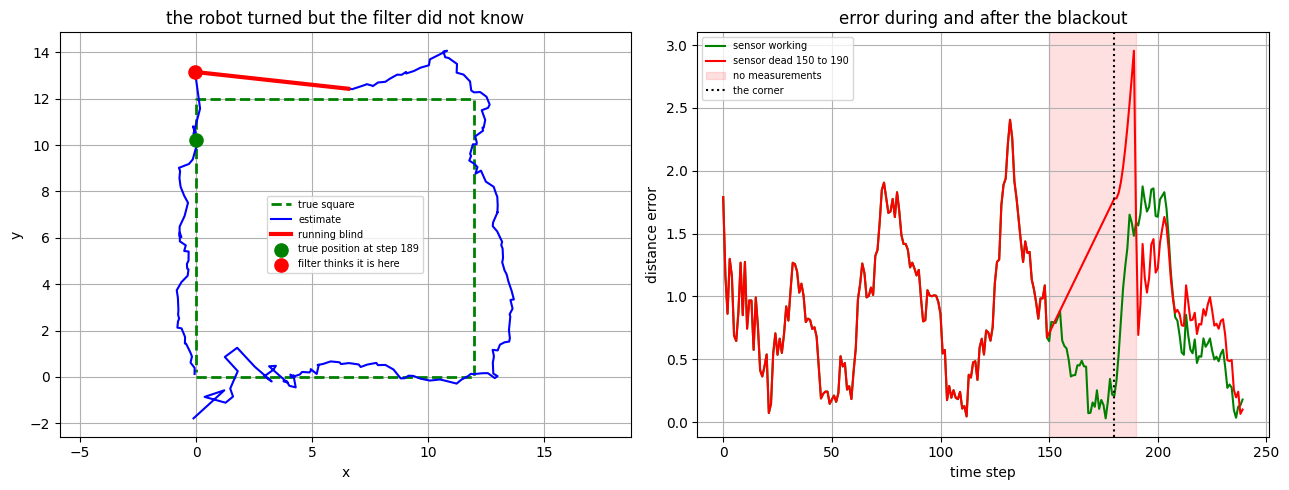

In [42]:
plt.figure(figsize=(13,5))
plt.subplot(1,2,1)
plt.plot(true[:,0], true[:,2], 'g--', linewidth=2, label="true square")
plt.plot(est_fail[:,0], est_fail[:,2], 'b', linewidth=1.5, label="estimate")
plt.plot(est_fail[150:190,0], est_fail[150:190,2], 'r', linewidth=3, label="running blind")
plt.scatter([true[189,0]], [true[189,2]], c='green', s=90, zorder=5, label="true position at step 189")
plt.scatter([est_fail[189,0]], [est_fail[189,2]], c='red', s=90, zorder=5, label="filter thinks it is here")
plt.xlabel("x"); plt.ylabel("y"); plt.axis('equal')
plt.title("the robot turned but the filter did not know")
plt.legend(fontsize=7); plt.grid(True)
plt.subplot(1,2,2)
plt.plot(np.linalg.norm(est_ok[:, [0,2]] - true[:, [0,2]], axis=1), 'g', label="sensor working")
plt.plot(np.linalg.norm(est_fail[:, [0,2]] - true[:, [0,2]], axis=1), 'r', label="sensor dead 150 to 190")
plt.axvspan(150, 190, color='red', alpha=0.12, label="no measurements")
plt.axvline(180, color='black', linestyle=':', label="the corner")
plt.xlabel("time step"); plt.ylabel("distance error")
plt.title("error during and after the blackout")
plt.legend(fontsize=7); plt.grid(True)
plt.tight_layout(); plt.show()